In [1]:
import os
os.unsetenv('PYTHONHOME') # Solve an issue with NEURON simulator import
!pip install -q bluepyopt==1.5.12 matplotlib==2.0.2 numpy==1.13.0 neurom==1.4.2 2>&1 | grep -v 'SNIMissingWarning\|InsecurePlatformWarning'

%matplotlib inline
import matplotlib.pyplot as pyplot

import os
import zipfile # Extract zip files
import urllib # Download files from the web
import neurom # Analyse / view morphologies
import neurom.viewer

DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip, can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support
    ERROR: Command errored out with exit status 1:
     command: /opt/conda/envs/python2/bin/python -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-ooZPVp/neurom/setup.py'"'"'; __file__='"'"'/tmp/pip-install-ooZPVp/neurom/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' egg_info --egg-base /tmp/pip-pip-egg-info-hhGFC3
         cwd: /tmp/pip-install-ooZPVp/neurom/
    Complete output (5 lines):
    Traceback (most recent call last):
      File "<string>", line 1, in <module>
      File "/tmp/pip-install-ooZPV

/opt/conda/envs/python2/lib/python2.7/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters


In [2]:
urllib.urlretrieve('https://senselab.med.yale.edu/modeldb/eavBinDown.cshtml?o=123623&a=23&mime=application/zip','PospischilEtAl2008.zip');

In [3]:
import os, zipfile
with zipfile.ZipFile('PospischilEtAl2008.zip', 'r') as zip_file:
    zip_file.extractall('.')

In [4]:
os.chdir('PospischilEtAl2008')

In [5]:
!nrnivmodl

/home/jovyan/PospischilEtAl2008
HH_traub.mod IL_gutnick.mod IM_cortex.mod IT_huguenard.mod cadecay_destexhe.mod
HH_traub.mod IL_gutnick.mod IM_cortex.mod IT_huguenard.mod cadecay_destexhe.mod
"/usr/local/nrn/x86_64/bin/nocmodl" HH_traub
Translating HH_traub.mod into HH_traub.c
Notice: VERBATIM blocks are not thread safe
Notice: This mechanism cannot be used with CVODE
"/usr/local/nrn/share/nrn/libtool" --tag=CC --mode=compile gcc -DHAVE_CONFIG_H  -I. -I.. -I"/usr/local/nrn/include/nrn" -I"/usr/local/nrn/x86_64/lib"      -g -O2 -c -o HH_traub.lo `test -f 'HH_traub.c' || echo '/'`HH_traub.c
libtool: compile:  gcc -DHAVE_CONFIG_H -I. -I.. -I/usr/local/nrn/include/nrn -I/usr/local/nrn/x86_64/lib -g -O2 -c HH_traub.c  -fPIC -DPIC -o .libs/HH_traub.o
"/usr/local/nrn/x86_64/bin/nocmodl" IL_gutnick
Translating IL_gutnick.mod into IL_gutnick.c
Thread Safe
"/usr/local/nrn/share/nrn/libtool" --tag=CC --mode=compile gcc -DHAVE_CONFIG_H  -I. -I.. -I"/usr/local/nrn/include/nrn" -I"/usr/local/nrn/x86

In [6]:
ls

cadecay_destexhe.mod  demo_PY_RS.hoc  IT_huguenard.mod  sPYbr_template
demo_IN_FS.hoc        fig5b.jpg       mosinit.hoc       sPYb_template
demo_PY_IB.hoc        HH_traub.mod    README.html       sPYr_template
demo_PY_IBR.hoc       IL_gutnick.mod  rundemo.hoc       sPY_template
demo_PY_LTS.hoc       IM_cortex.mod   sIN_template      x86_64/


In [7]:
import neuron as nrn # NEURON simulator

In [8]:
print nrn.h
# Load external files
nrn.h.load_file("stdrun.hoc");

In [9]:
nrn.h.load_file("mosinit.hoc");

In [10]:
nrn.h.load_file("demo_PY_IBR.hoc");

In [11]:
soma = nrn.h.Section(name='soma')

print "Soma object:", soma
print "Soma object name: ", soma.name()

soma.nseg = 1 #
soma.diam = 96 #
soma.L = 96 #			// so that area is about 29000 um2
soma.cm = 1 #
soma.Ra = 100 #		// geometry 

print "Number of segments in the soma:", soma.nseg
print soma.diam
print soma.L
print soma.cm
print soma.Ra 

Soma object: <nrn.Section object at 0x7fe303112e18>
Soma object name:  soma
Number of segments in the soma: 1
96.0
96.0
1.0
100.0


In [12]:
print "Simulation stop time: %f ms" % nrn.h.tstop
print "Integration time step: %f ms" % nrn.h.dt

time = nrn.h.Vector()
voltage = nrn.h.Vector()

time.record(nrn.h._ref_t)
voltage.record(soma(.5)._ref_v);

iclamp = nrn.h.IClamp(.5, sec=soma)
iclamp.amp = 0.15 # nA
iclamp.delay = 500 # ms
iclamp.dur = 2000 # ms

Simulation stop time: 3000.000000 ms
Integration time step: 0.100000 ms


In [13]:
soma.insert('pas');
soma.e_pas = -85
soma.g_pas = 1e-5 #		// idem TC cell

In [14]:
soma.insert('hh2'); #		// Hodgin-Huxley INa and IK 
soma.ek = -100 #		// potassium reversal potential 
soma.ena = 50 #			// sodium reversal potential 
soma.vtraub_hh2 = -55 #	// Resting Vm, BJ was -55
soma.gnabar_hh2 = 0.05 #	// McCormick=15 muS, thal was 0.09
soma.gkbar_hh2 = 0.005 #	// spike duration of pyr cells
celsius = 36
v_init = -84

In [15]:
soma.insert('im'); #		// M current 
taumax_im = 1000
soma.gkbar_im = 3e-5 #		// specific to LTS pyr cell

In [16]:
soma.insert('cad');  #		// calcium decay
soma.depth_cad = 1 #		// McCormick= 0.1 um
soma.taur_cad = 5 #		// McCormick=1 ms !!!
soma.cainf_cad = 2.4e-4 #	// McCormick=0
soma.kt_cad = 0 #		// no pump

In [17]:
soma.insert('ical'); #// IL current (Reuveni et al. model, Nernst)
soma.cai = 2.4e-4 
soma.cao = 2 
#soma.eca = 120 
soma.gcabar_ical = 2.2e-4

In [18]:
soma.insert('it'); #// IT current 
soma.cai = 2.4e-4 
soma.cao = 2 
#eca = 120 
soma.gcabar_it = 0.0004 #// specific to LTS pyr cell

In [19]:
nrn.h.tstop = 3000
nrn.h.dt = 0.01
print "Simulation stop time: %f ms" % nrn.h.tstop
print "Integration time step: %f ms" % nrn.h.dt

iclamp = nrn.h.IClamp(.5, sec=soma)
iclamp.amp = 0.15 # nA
iclamp.delay = 500 # ms
iclamp.dur = 2000 # ms

Simulation stop time: 3000.000000 ms
Integration time step: 0.010000 ms


In [20]:
soma.depth_cad = 1 #		// McCormick= 0.1 um

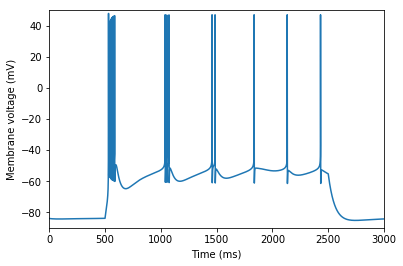

In [25]:
time = nrn.h.Vector()
voltage = nrn.h.Vector()
#mthh2 = nrn.h.Vector()
#hthh2 = nrn.h.Vector()
#nthh2 = nrn.h.Vector()
#mtim = nrn.h.Vector()
#mtical = nrn.h.Vector()
#htical = nrn.h.Vector()
#caitcad = nrn.h.Vector()
#icatcad = nrn.h.Vector()
#ecatcad = nrn.h.Vector()
stim_current = nrn.h.Vector()


stim_current.record(iclamp._ref_i)
time.record(nrn.h._ref_t)
voltage.record(soma(.5)._ref_v);
#mthh2.record(soma(.5)._ref_m_hh2);
#hthh2.record(soma(.5)._ref_h_hh2);
#nthh2.record(soma(.5)._ref_n_hh2);
#mtim.record(soma(.5)._ref_m_im);
#mtical.record(soma(.5)._ref_m_ical);
#htical.record(soma(.5)._ref_h_ical);
#caitcad.record(soma(.5)._ref_cai);
#icatcad.record(soma(.5)._ref_ica);
#ecatcad.record(soma(.5)._ref_eca);

nrn.h.run()

def plot_tv(time_array, voltage_array, show=True, label=None, ylabel='Membrane voltage (mV)', xyaxis=[2690, 3000, -85, 50] , constants=[]):
    import matplotlib.pyplot as plt
    import numpy
    plt.plot(time_array, voltage_array, label=label)
    for constant in constants:
        plt.plot(time_array, constant*numpy.ones(len(time_array)))
    plt.xlabel('Time (ms)')
    plt.ylabel(ylabel)
    plt.axis(xyaxis)
    if show:
        plt.show()

xinitial = 0
xfinal = 3000
plot_tv(time, voltage, ylabel='Membrane voltage (mV)', xyaxis=[xinitial, xfinal, -90, 50])
#plot_tv(time, mthh2, ylabel='m_hh2', xyaxis=[xinitial, xfinal, 0, 1])
#plot_tv(time, hthh2, ylabel='h_hh2', xyaxis=[xinitial, xfinal, 0, 1])
#plot_tv(time, nthh2, ylabel='n_hh2', xyaxis=[xinitial, xfinal, 0, 1])
#plot_tv(time, mtim, ylabel='m_im', xyaxis=[xinitial, xfinal, 0, 1])
#plot_tv(time, mtical, ylabel='m_ical', xyaxis=[xinitial, xfinal, 0, 1])
#plot_tv(time, htical, ylabel='h_ical', xyaxis=[xinitial, xfinal, 0.6, 0.8])
#plot_tv(time, caitcad, ylabel='cai_cad', xyaxis=[xinitial, xfinal, 0.0002, 0.004])
#plot_tv(time, icatcad, ylabel='ica', xyaxis=[xinitial, xfinal, -0.02, 0.0001])
#plot_tv(time, ecatcad, ylabel='Eca', xyaxis=[xinitial, xfinal, 80, 125.0])


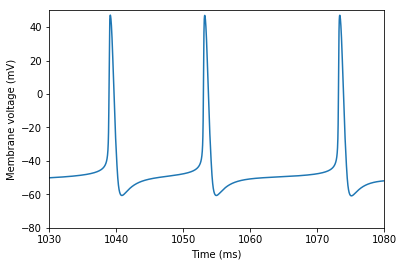

In [26]:
plot_tv(time, voltage, ylabel='Membrane voltage (mV)', xyaxis=[1030, 1080, -80, 50])

In [23]:
print soma.eca
print soma.ica
print soma.cai
print soma.v
print soma.m_ical
print soma.h_ical

120.049443488
-1.33921504145e-05
0.000243459683818
-84.293389992
5.49238121972e-07
0.676543957285


In [24]:
from __future__ import division
from neuron import h
from neuron import gui
import matplotlib.pyplot as plt
import numpy as np
plt.ion()

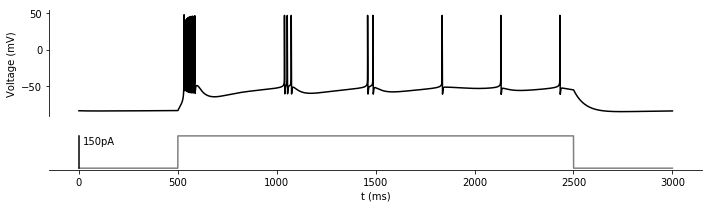

In [48]:
f, (ax0, ax1) = plt.subplots(2,1, figsize=(10,3), gridspec_kw = {'height_ratios':[3, 1]})
ax0.plot(time,voltage, 'k')
ax1.plot(time,stim_current, 'gray')

ax0.set_ylabel('Voltage (mV)')
ax0.spines['right'].set_visible(False)
ax0.spines['top'].set_visible(False)
ax0.spines['bottom'].set_visible(False)
ax0.get_xaxis().set_visible(False)


ax1.plot([0,0],[0,0.15],'k')
ax1.text(20,0.125,'150pA',va='center')
ax1.set_ylabel('I (nA)')
ax1.set_xlabel('t (ms)')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.get_yaxis().set_visible(False)
plt.tight_layout()